Strategic Workforce Attrition Data Analysis

Project Overview

This notebook performs end-to-end data analysis on employee attrition across five related datasets:

| Dataset | Variable | Description |
|---|---|---|
| Employee.csv | `df` | Core employee records |
| Department.csv | `dt` | Department details and budgets |
| Manager.csv | `mg` | Manager profiles |
| Salary.csv | `sal` | Salary history |
| Attrition_date.csv | `at` | Employee exit events |

Notebook Structure
1. Imports & Setup
2. Data Loading
3. Data Cleaning — Employee Table
4. Data Cleaning — Department Table
5. Data Cleaning — Manager Table
6. Data Cleaning — Salary Table
7. Data Cleaning — Attrition Table
8. Exploratory Data Analysis (EDA)
9. Data Export
10. Visualizations


1. Imports & Setup

In [138]:
# ── Core libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from word2number import w2n

 2. Data Loading

2.1 Employee Table

In [139]:
# Load the Employee dataset
df = pd.read_csv('D:\Attrition_Analysis\Raw_data_set\Employee.csv')
df

<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:2: SyntaxWarning: invalid escape sequence '\A'
C:\Users\Aman\AppData\Local\Temp\ipykernel_20984\1548890222.py:2: SyntaxWarning: invalid escape sequence '\A'
  df = pd.read_csv('D:\Attrition_Analysis\Raw_data_set\Employee.csv')


,employee_id,first_name,last_name,gender,hire_date,salary,dept_id,manager_id,job_role,overtime_hours_per_month,performance_rating,attrition
0,2001,Diana,Brown,Female,2023-09-01,160000,2,1019,Analyst,7,3.0,0
1,2002,Ivy,Wilson,female,2019-10-15,38000,7,1025,Associate,7,4.0,0
2,2003,Olivia,Kim,Female,2022-08-31,112000,3,1024,Analyst,5,3.0,1
3,2004,Kevin,Johnson,male,2022-07-11,160000,6,1034,Analyst,9,5.0,0
4,2005,Bob,Wilson,female,2019-01-12,85k,99,9999,Manager,8,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1200,3179,Laura,Martinez,Female,2021-07-24,112000,3,1043,Senior Analyst,7,4.0,0
1201,2866,Jack,Lee,Female,2020-01-30,52000,2,1019,Lead,13,4.0,0
1202,2102,Ivy,Martinez,Female,2018-02-15,85000,7,1017,Lead,5,3.0,1
1203,2440,Jack,Wilson,Male,2023-02-06,160000,1,1026,Lead,14,3.0,0


2.2 Department Table

In [140]:
# Load the Department dataset
dt = pd.read_csv('D:\\Attrition_Analysis\\Raw_data_set\\Department.csv')
dt

,dept_id,dept_name,region,budget
0,1,Sales,West,2366891
1,2,Marketing,Remote,3944769
2,3,Engineering,East,1391743
3,4,Product,Remote,703355
4,5,HR,Remote,1862752
5,6,Finance,South,1996025
6,7,Operations,East,1907371
7,8,Legal,East,1517040
8,9,Customer Support,East,2853882
9,10,R&D,Remote,4130409


2.3 Manager Table

In [141]:
# Load the Manager dataset
mg = pd.read_csv('D:\\Attrition_Analysis\\Raw_data_set\\Manager.csv')
mg

,manager_id,manager_name,dept_id,hire_date,performance_rating
0,1001,Jane Smith,1,2012-05-20,4.0
1,1002,David Kim,7,2017-05-08,4.0
2,1003,Sarah Lee,4,2015-08-07,4.0
3,1004,Jane Martinez,12,2014-06-09,3.0
4,1005,Jane Brown,5,2019-12-03,4.0
5,1006,John Smith,11,2020-04-03,5.0
6,1007,Jane Kim,9,2017-03-18,5.0
7,1008,Sarah Martinez,5,2015-02-23,5.0
8,1009,Emma Smith,1,2011-08-09,5.0
9,1010,Tom Kim,12,2012-12-20,5.0


 2.4 Salary Table

In [142]:
# Load the Salary dataset
sal = pd.read_csv('D:\\Attrition_Analysis\\Raw_data_set\\Salary.csv')
sal

,salary_id,employee_id,effective_date,monthly_salary,reason
0,1,2001,2024-03-23,139971,Adjustment
1,2,2001,2023-12-31,126724,Annual Review
2,3,2002,2022-07-31,115565,Hire
3,4,2002,2021-08-19,84574,Hire
4,5,2003,2024-06-23,65066,Hire
...,...,...,...,...,...
2399,2400,3199,2023-11-19,132677,Annual Review
2400,2401,3199,2021-05-24,95049,Promotion
2401,2402,3199,2022-01-05,75213,Hire
2402,2403,3200,2021-07-18,52585,Annual Review


 Attrition Table

In [143]:
# Load the Attrition (Employee Exit) dataset
at = pd.read_csv('D:\\Attrition_Analysis\\Raw_data_set\\Attrition_date.csv')
at

,event_id,employee_id,attrition_date,attrition_reason,exit_interview_score
0,1,2003,2023-09-22,Career change,4.0
1,2,2013,2021-02-21,Relocation,NaN
2,3,2025,2022-03-08,Retirement,4.0
3,4,2027,2024-01-28,Retirement,1.0
4,5,2028,2023-12-14,Retirement,2.0
...,...,...,...,...,...
236,237,3171,2021-01-12,Relocation,5.0
237,238,3175,2020-05-13,Retirement,2.0
238,239,3191,2024-11-07,Career change,2.0
239,240,2102,2019-04-25,Retirement,5.0


3. Data Cleaning — Employee Table (`df`)

3.1 Initial Inspection

In [144]:
# Display raw column names before cleaning
df.columns

Index(['employee_id', 'first_name', 'last_name', 'gender', 'hire_date',
       'salary', 'dept_id', 'manager_id', 'job_role',
       'overtime_hours_per_month', 'performance_rating', 'attrition'],
      dtype='str')

In [145]:
display(df.info())      # Review dataset structure, data types, and missing values
display(df.describe())  # Generate descriptive statistics
display(df.head(10))    # Preview dataset

<class 'pandas.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   employee_id               1205 non-null   int64  
 1   first_name                1205 non-null   str    
 2   last_name                 1205 non-null   str    
 3   gender                    1205 non-null   str    
 4   hire_date                 1205 non-null   str    
 5   salary                    1205 non-null   str    
 6   dept_id                   1205 non-null   int64  
 7   manager_id                1205 non-null   int64  
 8   job_role                  1205 non-null   str    
 9   overtime_hours_per_month  1205 non-null   int64  
 10  performance_rating        1180 non-null   float64
 11  attrition                 1205 non-null   int64  
dtypes: float64(1), int64(5), str(6)
memory usage: 113.1 KB


None

,employee_id,dept_id,manager_id,overtime_hours_per_month,performance_rating,attrition
count,1205.000000,1205.000000,1205.000000,1205.000000,1180.000000,1205.000000
mean,2600.204149,21.400830,2490.205809,7.907054,3.568644,0.199170
std,346.999995,34.486641,3320.903585,2.905429,0.908652,0.399542
min,2001.000000,1.000000,1001.000000,-4.000000,1.000000,0.000000
25%,2300.000000,3.000000,1014.000000,6.000000,3.000000,0.000000
50%,2600.000000,7.000000,1027.000000,8.000000,4.000000,0.000000
75%,2900.000000,11.000000,1041.000000,10.000000,4.000000,0.000000
max,3200.000000,99.000000,9999.000000,18.000000,5.000000,1.000000


,employee_id,first_name,last_name,gender,hire_date,salary,dept_id,manager_id,job_role,overtime_hours_per_month,performance_rating,attrition
0,2001,Diana,Brown,Female,2023-09-01,160000,2,1019,Analyst,7,3.0,0
1,2002,Ivy,Wilson,female,2019-10-15,38000,7,1025,Associate,7,4.0,0
2,2003,Olivia,Kim,Female,2022-08-31,112000,3,1024,Analyst,5,3.0,1
3,2004,Kevin,Johnson,male,2022-07-11,160000,6,1034,Analyst,9,5.0,0
4,2005,Bob,Wilson,female,2019-01-12,85k,99,9999,Manager,8,2.0,0
5,2006,Nick,Rodriguez,Female,2021-12-02,98000,3,1024,Analyst,12,5.0,0
6,2007,Laura,Rodriguez,Male,2020-06-25,fifty two thousand,2,1044,Analyst,6,3.0,0
7,2008,Laura,Rodriguez,Male,2020-05-23,61k,4,1029,Analyst,9,2.0,0
8,2009,Frank,Johnson,female,2021-09-21,38000,99,9999,Analyst,9,3.0,0
9,2010,Eve,Wilson,Female,2021-09-18,98000,3,1043,Lead,8,4.0,0


3.2 Column Name Cleanup

In [146]:
# Strip leading and trailing whitespace from all column names
df.columns = df.columns.str.strip()

 3.3 employee_id — Duplicates & Missing Values

In [147]:
# Check missing values in employee_id
df['employee_id'].isnull().sum()

np.int64(0)

In [148]:
df['employee_id'].duplicated().unique().sum()  # Check duplicate employee IDs

np.int64(1)

In [149]:
# Remove duplicate employee records based on employee_id
print(f"Original rows: {len(df)}")
df = df.drop_duplicates(subset='employee_id', keep='first')
print(f"Rows after deleteduplicate: {len(df)}")

Original rows: 1205
Rows after deleteduplicate: 1200


 3.4 Name Columns — Whitespace & Title Case

In [150]:
# Remove leading and trailing spaces, and apply title case to first_name
df['first_name'] = df['first_name'].str.strip().str.title()
df['first_name']

0        Diana
1          Ivy
2       Olivia
3        Kevin
4          Bob
         ...  
1195      Jack
1196      Jack
1197       Bob
1198     Kevin
1199       Bob
Name: first_name, Length: 1200, dtype: str

In [151]:
# Remove leading and trailing spaces, and apply title case to last_name
df['last_name'] = df['last_name'].str.strip().str.title()
df['last_name']

0         Brown
1        Wilson
2           Kim
3       Johnson
4        Wilson
         ...   
1195      Smith
1196        Kim
1197     Wilson
1198     Wilson
1199    Johnson
Name: last_name, Length: 1200, dtype: str

3.5 gender — Missing Values & Standardization

In [152]:
# Check missing values in gender
df['gender'].isnull().sum()

# Review gender categories
df['gender'].value_counts()

gender
Male      306
Female    299
female    163
male      123
m          78
f          63
F          63
Man        58
M          47
Name: count, dtype: int64

In [153]:
df['gender'].unique()  # Check unique values in gender column

<StringArray>
['Female', 'female', 'male', 'Male', 'f', 'm', 'F', 'Man', 'M']
Length: 9, dtype: str

In [154]:
# Standardize gender values (remove spaces, normalize case)
df['gender'] = df['gender'].str.strip().str.lower().str.capitalize()
gender_map = {          # Map inconsistent gender labels to standard categories
    'Female': 'Female',
    'F': 'Female',
    'Woman': 'Female',
    'Male': 'Male',
    'M': 'Male',
    'Man': 'Male'
    }
df['gender'] = df['gender'].map(gender_map).fillna('Unknown')
print(df['gender'].unique())

<StringArray>
['Female', 'Male']
Length: 2, dtype: str


3.6 hire_date — Format & Datetime Conversion

In [155]:
# Preview raw hire_date values
df['hire_date']

0       2023-09-01
1       2019-10-15
2       2022-08-31
3       2022-07-11
4       2019-01-12
           ...    
1195    2019-06-23
1196    2020-01-27
1197    2018-04-18
1198    2020-12-29
1199    2020-08-03
Name: hire_date, Length: 1200, dtype: str

In [156]:
display(df['hire_date'].unique())       # Check unique hire dates
display(df['hire_date'].nunique())      # Count unique hire dates
display(df['hire_date'].value_counts()) # Frequency of hire dates

<StringArray>
['2023-09-01', '2019-10-15', '2022-08-31', '2022-07-11', '2019-01-12',
 '2021-12-02', '2020-06-25', '2020-05-23', '2021-09-21', '2021-09-18',
 ...
 '2022-08-23', '2022-08-12', '2021-05-27', '2021-01-26', '2019-09-15',
 '2019-03-14', '2019-06-23', '2020-01-27', '2020-12-29', '2020-08-03']
Length: 945, dtype: str

945

hire_date
2022-04-12    4
2021-06-02    4
2020-12-14    4
2020-11-21    4
2022-12-31    3
             ..
2019-03-14    1
2019-06-23    1
2020-01-27    1
2020-12-29    1
2020-08-03    1
Name: count, Length: 945, dtype: int64

In [157]:
# Convert hire_date to datetime format
df['hire_date'] = pd.to_datetime(df['hire_date'], errors='coerce')
df['hire_date'].head()

0   2023-09-01
1   2019-10-15
2   2022-08-31
3   2022-07-11
4   2019-01-12
Name: hire_date, dtype: datetime64[us]

In [158]:
# Verify datetime conversion and check for parsing failures
display(df['hire_date'].dtype)
display(df['hire_date'].isnull().sum())

dtype('<M8[us]')

np.int64(0)

3.7 salary — Cleaning & Imputation

In [159]:
df['salary'].unique()  # Check unique salary values

<StringArray>
[                '160000',                  '38000',                 '112000',
                    '85k',                  '98000',     'fifty two thousand',
                    '61k',                  '61000',                    '45k',
                 '135000',         'thirty eight k',                  '73000',
                  '52000',                  '45000',         'ninety eight k',
 'seventy three thousand',                  '85000',                   'zero']
Length: 18, dtype: str

In [160]:
df.loc[df['salary'] == 'zero']  # Identify problematic values like 'zero'

,employee_id,first_name,last_name,gender,hire_date,salary,dept_id,manager_id,job_role,overtime_hours_per_month,performance_rating,attrition
551,2552,Henry,Kim,Male,2020-05-12,zero,4,1023,Lead,4,2.0,0


In [161]:
# Inspect the specific employee record with a problematic salary
df.loc[df['employee_id'] == 2552]

,employee_id,first_name,last_name,gender,hire_date,salary,dept_id,manager_id,job_role,overtime_hours_per_month,performance_rating,attrition
551,2552,Henry,Kim,Male,2020-05-12,zero,4,1023,Lead,4,2.0,0


In [162]:
# Custom function to parse salary values in various formats (numeric, word, currency symbols, 'k' notation)
def clean_salary(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()

    # Remove currency symbols and commas
    x = x.replace('$', '').replace('₹', '').replace(',', '')

    # Handle 'k' (e.g., 85k, sixty k)
    if 'k' in x:
        # Remove 'k' and try to convert numeric part
        num_part = x.replace('k', '').strip()
        try:
            # If numeric, e.g., '85'
            return float(num_part) * 1000
        except:
            # If word like 'sixty', use w2n
            try:
                return w2n.word_to_num(num_part) * 1000
            except:
                return np.nan

    # Handle 'zero'
    if x == 'zero' or x == 0 or x == '0':
        return np.nan

    # Try word2number for phrases like 'fifty two thousand'
    try:
        return float(w2n.word_to_num(x))
    except:
        pass

    # Try direct float conversion
    try:
        return float(x)
    except:
        return np.nan

# Apply the cleaning function to the salary column
df['salary'] = df['salary'].apply(clean_salary)

# Fill missing salary with median per job role
df['salary'] = df.groupby('job_role')['salary'].transform(lambda x: x.fillna(x.median()))

# Ensure salary is stored as float
df['salary'] = df['salary'].astype(float)

print(df['salary'].head())

0    160000.0
1     38000.0
2    112000.0
3    160000.0
4     85000.0
Name: salary, dtype: float64


In [163]:
# Verify salary values after cleaning
df['salary'].unique()

array([160000.,  38000., 112000.,  85000.,  98000.,  52000.,  61000.,
        45000., 135000.,  73000.,  79000.])

In [164]:
# Confirm the previously problematic employee record is now fixed
df.loc[df['employee_id'] == 2552]

,employee_id,first_name,last_name,gender,hire_date,salary,dept_id,manager_id,job_role,overtime_hours_per_month,performance_rating,attrition
551,2552,Henry,Kim,Male,2020-05-12,79000.0,4,1023,Lead,4,2.0,0


 3.8 dept_id — Invalid Value Handling

In [165]:
# Check unique department IDs in employee table
df['dept_id'].unique()

array([ 2,  7,  3,  6, 99,  4, 10,  1,  8,  9, 11, 12,  5])

In [166]:
# Replace invalid department ID (99) with NaN
df['dept_id'] = df['dept_id'].replace(99, np.nan)

In [167]:
# Check distribution after cleaning
df['dept_id'].value_counts()

dept_id
3.0     183
1.0     122
9.0      99
7.0      95
10.0     94
11.0     89
12.0     84
2.0      62
4.0      51
6.0      47
5.0      40
8.0      37
Name: count, dtype: int64

In [168]:
# Check missing values in dept_id
df['dept_id'].isnull().sum()

np.int64(197)

 3.9 manager_id — Invalid Value Handling

In [169]:
# Check unique manager IDs in employee table
df['manager_id'].unique()

array([1019, 1025, 1024, 1034, 9999, 1044, 1029, 1043, 1018, 1026, 1015,
       1001, 1038, 1037, 1042, 1032, 1007, 1014, 1006, 1021, 1009, 1023,
       1022, 1039, 1016, 1031, 1035, 1008, 1010, 1040, 1041, 1036, 1027,
       1028, 1033, 1017, 1002, 1013, 1005, 1003, 1045, 1030, 1012, 1020,
       1011, 1004])

In [170]:
# Replace invalid manager ID (9999) with NaN
df['manager_id'] = df['manager_id'].replace(9999, np.nan)

 3.10 job_role — Whitespace Cleanup

In [171]:
df['job_role'].unique()  # Check unique job roles in the dataset

<StringArray>
['Analyst', 'Associate', 'Manager', 'Lead', 'Senior Analyst', 'Director',
 'VP']
Length: 7, dtype: str

In [172]:
# Remove leading and trailing spaces from job_role values
df['job_role'] = df['job_role'].str.strip()

 3.11 overtime_hours_per_month — Negative Values & Imputation

In [173]:
# Check unique values in overtime_hours_per_month
display(df['overtime_hours_per_month'].unique())

# Check frequency distribution
display(df['overtime_hours_per_month'].value_counts())

array([ 7,  5,  9,  8, 12,  6,  4, 13, 11, 10,  1,  3, 14, -4,  2, 15, 16,
       18])

overtime_hours_per_month
 8     155
 7     151
 9     145
 10    138
 6     131
 5     118
 11    100
 4      82
 12     50
 3      38
 13     36
 2      17
 15     13
 14     12
 1       5
 18      4
 16      3
-4       2
Name: count, dtype: int64

In [174]:
# Replace invalid negative values with NaN
df.loc[df['overtime_hours_per_month'] < 0, 'overtime_hours_per_month'] = np.nan

In [175]:
# Fill missing values with median overtime hours grouped by job_role
df['overtime_hours_per_month'] = df.groupby('job_role')['overtime_hours_per_month'].transform(
    lambda x: x.fillna(x.median()))

 3.12 performance_rating — Missing Value Imputation

In [176]:
# Check unique performance ratings
display(df['performance_rating'].unique())

# Check frequency distribution
display(df['performance_rating'].value_counts())

array([ 3.,  4.,  5.,  2.,  1., nan])

performance_rating
4.0    475
3.0    417
5.0    169
2.0     85
1.0     29
Name: count, dtype: int64

In [177]:
# Fill missing performance_rating with median per job role
df['performance_rating'] = df.groupby('job_role')['performance_rating'].transform(
    lambda x: x.fillna(x.median()))
df['performance_rating']

0       3.0
1       4.0
2       3.0
3       5.0
4       2.0
       ... 
1195    5.0
1196    1.0
1197    3.0
1198    3.0
1199    4.0
Name: performance_rating, Length: 1200, dtype: float64

 3.13 attrition — Review Distribution

In [178]:
# Check unique values in attrition column
display(df['attrition'].unique())

# Check distribution of attrition values
display(df['attrition'].value_counts())

array([0, 1])

attrition
0    961
1    239
Name: count, dtype: int64

 3.14 Final Employee Table Review

In [179]:
# Final overview of the cleaned employee table
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   employee_id               1200 non-null   int64         
 1   first_name                1200 non-null   str           
 2   last_name                 1200 non-null   str           
 3   gender                    1200 non-null   str           
 4   hire_date                 1200 non-null   datetime64[us]
 5   salary                    1200 non-null   float64       
 6   dept_id                   1003 non-null   float64       
 7   manager_id                1003 non-null   float64       
 8   job_role                  1200 non-null   str           
 9   overtime_hours_per_month  1200 non-null   float64       
 10  performance_rating        1200 non-null   float64       
 11  attrition                 1200 non-null   int64         
dtypes: datetime64[us](1), float64(5

In [180]:
# Preview salary values by job role after cleaning
df[['job_role', 'salary']].sort_values('job_role').reset_index(drop=True)

,job_role,salary
0,Analyst,160000.0
1,Analyst,45000.0
2,Analyst,112000.0
3,Analyst,98000.0
4,Analyst,73000.0
...,...,...
1195,VP,160000.0
1196,VP,112000.0
1197,VP,160000.0
1198,VP,135000.0


4. Data Cleaning — Department Table (`dt`)

4.1 Initial Inspection

In [181]:
# Display raw column names before cleaning
dt.columns

Index(['dept_id', 'dept_name', 'region', 'budget'], dtype='str')

In [182]:
# Dataset overview
display(dt.info())

# Summary statistics
display(dt.describe())

# Preview dataset
display(dt.head())

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   dept_id    12 non-null     int64
 1   dept_name  12 non-null     str  
 2   region     12 non-null     str  
 3   budget     12 non-null     int64
dtypes: int64(2), str(2)
memory usage: 516.0 bytes


None

,dept_id,budget
count,12.000000,1.200000e+01
mean,6.500000,2.469601e+06
std,3.605551,1.244628e+06
min,1.000000,7.033550e+05
25%,3.750000,1.776324e+06
50%,6.500000,2.048484e+06
75%,9.250000,3.126604e+06
max,12.000000,4.860029e+06


,dept_id,dept_name,region,budget
0,1,Sales,West,2366891
1,2,Marketing,Remote,3944769
2,3,Engineering,East,1391743
3,4,Product,Remote,703355
4,5,HR,Remote,1862752


4.2 Column Name Cleanup

In [183]:
# Strip leading and trailing whitespace from all column names
dt.columns = dt.columns.str.strip()

 4.3 dept_id — Duplicates Check

In [184]:
# Count unique department IDs
display(dt['dept_id'].nunique())

# Check duplicate department IDs
display(dt['dept_id'].duplicated().sum())

12

np.int64(0)

4.4 dept_name — Whitespace Cleanup

In [185]:
# Remove leading and trailing spaces from department names
dt['dept_name'] = dt['dept_name'].str.strip()
dt['dept_name']

0                 Sales
1             Marketing
2           Engineering
3               Product
4                    HR
5               Finance
6            Operations
7                 Legal
8      Customer Support
9                   R&D
10         Data Science
11    IT Infrastructure
Name: dept_name, dtype: str

 4.5 region — Whitespace Cleanup

In [186]:
# Inspect unique region values before cleaning
dt['region'].unique()

<StringArray>
['West', 'Remote', 'East', 'South']
Length: 4, dtype: str

In [187]:
# Remove leading and trailing spaces from region values
dt['region'] = dt['region'].str.strip()
dt

,dept_id,dept_name,region,budget
0,1,Sales,West,2366891
1,2,Marketing,Remote,3944769
2,3,Engineering,East,1391743
3,4,Product,Remote,703355
4,5,HR,Remote,1862752
5,6,Finance,South,1996025
6,7,Operations,East,1907371
7,8,Legal,East,1517040
8,9,Customer Support,East,2853882
9,10,R&D,Remote,4130409


4.6 budget — Missing Values & Outlier Detection

In [188]:
# Check for missing values in budget
display(dt['budget'].isnull().sum())

# Review summary statistics
display(dt['budget'].describe())

np.int64(0)

count    1.200000e+01
mean     2.469601e+06
std      1.244628e+06
min      7.033550e+05
25%      1.776324e+06
50%      2.048484e+06
75%      3.126604e+06
max      4.860029e+06
Name: budget, dtype: float64

In [189]:
# Replace invalid (zero or negative) budget values with NaN
dt.loc[dt['budget'] <= 0, 'budget'] = np.nan

In [190]:
# Detect outliers using the IQR method
q1 = dt['budget'].quantile(.25)
print(f'q1={q1}')
q3 = dt['budget'].quantile(.75)
print(f'q3={q3}')
iqr = q3 - q1
print(f'IQR={iqr}')
lower = q1 - 1.5 * iqr
print(f'lower_bound={lower}')
upper = q3 + 1.5 * iqr
print(f'upper_bound={upper}')

outliers = (dt['budget'] < lower) | (dt['budget'] > upper)
print(f'outliers={outliers.sum()}')

q1=1776324.0
q3=3126603.75
IQR=1350279.75
lower_bound=-249095.625
upper_bound=5152023.375
outliers=0


4.7 Exploratory Questions — Department Table

Q1. Which department has the highest budget?

In [191]:
dt.sort_values('budget', ascending=False).head()

,dept_id,dept_name,region,budget
11,12,IT Infrastructure,East,4860029.0
9,10,R&D,Remote,4130409.0
1,2,Marketing,Remote,3944769.0
8,9,Customer Support,East,2853882.0
0,1,Sales,West,2366891.0


The IT Infrastructure department has the highest budget (4,860,029), indicating significant investment in technology and operational support.

Q2. What is the regional distribution of departments?

In [192]:
dt['region'].value_counts()

region
East      5
Remote    4
West      2
South     1
Name: count, dtype: int64

Most departments are located in the East region (5 departments), followed by Remote operations (4 departments).

Q3. What is the average departmental budget?

In [193]:
dt['budget'].mean().round()

np.float64(2469601.0)

The average departmental budget is approximately 2,469,601.0

**Department Budget Insight**

Department budgets are unevenly distributed, with IT Infrastructure receiving the highest allocation, indicating priority investment in technical operations.

5. Data Cleaning — Manager Table (`mg`)

 5.1 Initial Inspection

In [194]:
# Display raw column names before cleaning
mg.columns

Index(['manager_id', 'manager_name', 'dept_id', 'hire_date',
       'performance_rating'],
      dtype='str')

In [195]:
# Strip leading and trailing whitespace from all column names
mg.columns = mg.columns.str.strip()

In [196]:
# Review dataset structure, data types, and missing values
display(mg.info())

# Generate descriptive statistics
display(mg.describe())

<class 'pandas.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   manager_id          46 non-null     int64  
 1   manager_name        46 non-null     str    
 2   dept_id             46 non-null     int64  
 3   hire_date           46 non-null     str    
 4   performance_rating  45 non-null     float64
dtypes: float64(1), int64(2), str(2)
memory usage: 1.9 KB


None

,manager_id,dept_id,performance_rating
count,46.000000,46.000000,45.000000
mean,1022.608696,6.108696,4.377778
std,13.255570,3.616187,0.613814
min,1001.000000,1.000000,3.000000
25%,1011.250000,3.000000,4.000000
50%,1022.500000,5.500000,4.000000
75%,1033.750000,9.000000,5.000000
max,1045.000000,12.000000,5.000000


 5.2 manager_id — Missing Values & Duplicates

In [197]:
# Check for missing values in manager_id
display(mg['manager_id'].isnull().sum())

# Review unique manager IDs
display(mg['manager_id'].nunique())

np.int64(0)

45

In [198]:
# Check duplicate manager IDs
mg['manager_id'].duplicated().sum()

np.int64(1)

In [199]:
# Remove duplicate manager records based on manager_id
print(f"Original rows: {len(mg)}")
mg = mg.drop_duplicates(subset='manager_id', keep='first')
print(f"Rows after deleteduplicate: {len(mg)}")

Original rows: 46
Rows after deleteduplicate: 45


 5.3 manager_name — Whitespace Cleanup

In [200]:
# Remove leading and trailing spaces from manager names
mg['manager_name'] = mg['manager_name'].str.strip()
mg['manager_name']

0         Jane Smith
1          David Kim
2          Sarah Lee
3      Jane Martinez
4         Jane Brown
5         John Smith
6           Jane Kim
7     Sarah Martinez
8         Emma Smith
9            Tom Kim
10         Tom Brown
11      Sarah Wilson
12        Emma Patel
13          John Lee
14      Chris Garcia
15         David Lee
16      Sarah Garcia
17      Jane Johnson
18     Chris Johnson
19       Lisa Garcia
20        Emma Patel
21       John Wilson
22       Tom Johnson
23     Chris Johnson
24         Tom Patel
25       Emma Garcia
26          Emma Kim
27        Jane Smith
28       Sarah Patel
29          Jane Kim
30        Jane Brown
31      David Wilson
32          Lisa Lee
33       Lisa Garcia
34       Sarah Patel
35          Jane Lee
36           Tom Kim
37       Mike Wilson
38       Chris Patel
39           Tom Kim
40        Lisa Smith
41       Sarah Smith
42        Lisa Brown
43     David Johnson
44      Sarah Garcia
Name: manager_name, dtype: str

5.4 hire_date — Format & Datetime Conversion

In [201]:
# Inspect hire_date values before conversion
display(mg['hire_date'].unique())
display(mg['hire_date'].nunique())
display(mg['hire_date'].value_counts())

<StringArray>
['2012-05-20', '2017-05-08', '2015-08-07', '2014-06-09', '2019-12-03',
 '2020-04-03', '2017-03-18', '2015-02-23', '2011-08-09', '2012-12-20',
 '2011-07-26', '2012-10-07', '2018-05-10', '2016-04-18', '2016-01-17',
 '2012-12-12', '2018-05-18', '2016-07-22', '2014-10-21', '2020-01-26',
 '2016-07-18', '2014-06-24', '2014-01-22', '2012-06-17', '2011-07-21',
 '2015-09-19', '2015-07-15', '2011-01-08', '2018-06-23', '2010-07-12',
 '2019-08-29', '2011-03-26', '2011-09-19', '2017-01-14', '2011-10-18',
 '2018-11-19', '2017-08-19', '2014-09-26', '2016-09-08', '2010-09-18',
 '2014-04-26', '2014-04-13', '2016-09-06', '2015-04-02', '2015-12-08']
Length: 45, dtype: str

45

hire_date
2012-05-20    1
2017-05-08    1
2015-08-07    1
2014-06-09    1
2019-12-03    1
2020-04-03    1
2017-03-18    1
2015-02-23    1
2011-08-09    1
2012-12-20    1
2011-07-26    1
2012-10-07    1
2018-05-10    1
2016-04-18    1
2016-01-17    1
2012-12-12    1
2018-05-18    1
2016-07-22    1
2014-10-21    1
2020-01-26    1
2016-07-18    1
2014-06-24    1
2014-01-22    1
2012-06-17    1
2011-07-21    1
2015-09-19    1
2015-07-15    1
2011-01-08    1
2018-06-23    1
2010-07-12    1
2019-08-29    1
2011-03-26    1
2011-09-19    1
2017-01-14    1
2011-10-18    1
2018-11-19    1
2017-08-19    1
2014-09-26    1
2016-09-08    1
2010-09-18    1
2014-04-26    1
2014-04-13    1
2016-09-06    1
2015-04-02    1
2015-12-08    1
Name: count, dtype: int64

In [202]:
# Convert hire_date to datetime format
mg['hire_date'] = pd.to_datetime(mg['hire_date'], errors='coerce')
mg['hire_date']

0    2012-05-20
1    2017-05-08
2    2015-08-07
3    2014-06-09
4    2019-12-03
5    2020-04-03
6    2017-03-18
7    2015-02-23
8    2011-08-09
9    2012-12-20
10   2011-07-26
11   2012-10-07
12   2018-05-10
13   2016-04-18
14   2016-01-17
15   2012-12-12
16   2018-05-18
17   2016-07-22
18   2014-10-21
19   2020-01-26
20   2016-07-18
21   2014-06-24
22   2014-01-22
23   2012-06-17
24   2011-07-21
25   2015-09-19
26   2015-07-15
27   2011-01-08
28   2018-06-23
29   2010-07-12
30   2019-08-29
31   2011-03-26
32   2011-09-19
33   2017-01-14
34   2011-10-18
35   2018-11-19
36   2017-08-19
37   2014-09-26
38   2016-09-08
39   2010-09-18
40   2014-04-26
41   2014-04-13
42   2016-09-06
43   2015-04-02
44   2015-12-08
Name: hire_date, dtype: datetime64[us]

In [203]:
# Verify data type after conversion
mg['hire_date'].dtype

dtype('<M8[us]')

5.5 performance_rating — Invalid Values & Imputation

In [204]:
# Inspect performance_rating values and distribution
display(mg['performance_rating'].unique())
display(mg['performance_rating'].isnull().sum())  # Check missing values
display(mg['performance_rating'].value_counts())

array([ 4.,  3.,  5., nan])

np.int64(1)

performance_rating
4.0    21
5.0    20
3.0     3
Name: count, dtype: int64

In [205]:
# Review rating distribution in sorted order
mg['performance_rating'].value_counts().sort_index()

performance_rating
3.0     3
4.0    21
5.0    20
Name: count, dtype: int64

In [206]:
# Replace negative performance ratings with NaN (invalid entries)
mg.loc[mg['performance_rating'] < 0, 'performance_rating'] = np.nan

In [207]:
# Fill missing performance ratings using the overall median
mg['performance_rating'] = mg['performance_rating'].fillna(mg['performance_rating'].median())
mg['performance_rating']

0     4.0
1     4.0
2     4.0
3     3.0
4     4.0
5     5.0
6     5.0
7     5.0
8     5.0
9     5.0
10    5.0
11    5.0
12    4.0
13    3.0
14    4.0
15    5.0
16    5.0
17    4.0
18    4.0
19    4.0
20    4.0
21    5.0
22    5.0
23    5.0
24    4.0
25    4.0
26    3.0
27    5.0
28    4.0
29    4.0
30    4.0
31    5.0
32    4.0
33    4.0
34    5.0
35    4.0
36    5.0
37    4.0
38    4.0
39    5.0
40    4.0
41    5.0
42    5.0
43    5.0
44    4.0
Name: performance_rating, dtype: float64

5.6 dept_id — Referential Integrity Check

In [208]:
# Check missing values in dept_id
display(mg['dept_id'].isnull().sum())

# Review department IDs
display(mg['dept_id'].unique())

np.int64(0)

array([ 1,  7,  4, 12,  5, 11,  9,  3, 10,  2,  6])

In [209]:
# Verify that all manager dept_ids exist in the department table (referential integrity check)
set(mg['dept_id']) - set(dt['dept_id'])

set()

 5.7 Final Manager Table Review

In [210]:
# Review performance rating summary statistics after cleaning
mg['performance_rating'].describe()

count    45.000000
mean      4.377778
std       0.613814
min       3.000000
25%       4.000000
50%       4.000000
75%       5.000000
max       5.000000
Name: performance_rating, dtype: float64

In [211]:
# Final overview of the cleaned manager table
mg.info()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   manager_id          45 non-null     int64         
 1   manager_name        45 non-null     str           
 2   dept_id             45 non-null     int64         
 3   hire_date           45 non-null     datetime64[us]
 4   performance_rating  45 non-null     float64       
dtypes: datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 1.9 KB


6. Data Cleaning — Salary Table (`sal`)

 6.1 Initial Inspection

In [212]:
# Check dataset structure, data types, and missing values
display(sal.info())

# Generate descriptive statistics
display(sal.describe())

# Preview first few rows
display(sal.head())

<class 'pandas.DataFrame'>
RangeIndex: 2404 entries, 0 to 2403
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   salary_id       2404 non-null   int64
 1   employee_id     2404 non-null   int64
 2   effective_date  2394 non-null   str  
 3   monthly_salary  2404 non-null   int64
 4   reason          2404 non-null   str  
dtypes: int64(3), str(2)
memory usage: 94.0 KB


None

,salary_id,employee_id,monthly_salary
count,2404.000000,2404.000000,2404.000000
mean,1201.500416,2607.926373,108890.878536
std,694.118626,347.035268,42496.032578
min,1.000000,2001.000000,35018.000000
25%,600.750000,2310.750000,70839.250000
50%,1201.500000,2609.500000,111756.500000
75%,1802.250000,2914.250000,145605.000000
max,2403.000000,3200.000000,179973.000000


,salary_id,employee_id,effective_date,monthly_salary,reason
0,1,2001,2024-03-23,139971,Adjustment
1,2,2001,2023-12-31,126724,Annual Review
2,3,2002,2022-07-31,115565,Hire
3,4,2002,2021-08-19,84574,Hire
4,5,2003,2024-06-23,65066,Hire


In [213]:
sal.columns  # Show all columns

Index(['salary_id', 'employee_id', 'effective_date', 'monthly_salary',
       'reason'],
      dtype='str')

 6.2 Column Name Cleanup

In [214]:
# Remove leading and trailing spaces from column names
sal.columns = sal.columns.str.strip()

6.3 salary_id — Missing Values & Duplicates

In [215]:
sal['salary_id'].isna().sum()    # Check for missing values in salary_id

np.int64(0)

In [216]:
sal['salary_id'].unique()    # Review unique salary IDs

array([   1,    2,    3, ..., 2401, 2402, 2403], shape=(2403,))

In [217]:
sal['salary_id'].duplicated().sum()    # Check for duplicate salary IDs

np.int64(1)

In [218]:
# Remove duplicate records based on salary_id and keep the first occurrence
print(f"Original rows: {len(sal)}")
sal = sal.drop_duplicates(subset='salary_id', keep='first')
print(f"Rows after deleteduplicate: {len(sal)}")

Original rows: 2404
Rows after deleteduplicate: 2403


In [219]:
sal['salary_id'].duplicated().sum()  # Verify that no duplicate salary IDs remain

np.int64(0)

 6.4 effective_date — Missing Values & Datetime Conversion

In [220]:
display(sal['effective_date'].nunique())    # Check the number of unique effective dates
display(sal['effective_date'].isnull().sum())  # Check missing values in effective_date

1556

np.int64(10)

In [221]:
# Investigate employees with missing effective dates
missing_emp = sal.loc[sal['effective_date'].isna(), 'employee_id']
sal[sal['employee_id'].isin(missing_emp)].sort_values(
    ['employee_id', 'effective_date'])

,salary_id,employee_id,effective_date,monthly_salary,reason
450,451,2235,NaN,125805,Hire
718,719,2370,2023-09-24,176234,Adjustment
716,717,2370,2026-05-11,146466,Annual Review
717,718,2370,NaN,112264,Annual Review
991,992,2504,2020-05-18,157963,Annual Review
990,991,2504,NaN,42855,Annual Review
1007,1008,2511,2026-03-09,123047,Hire
1006,1007,2511,NaN,103759,Promotion
1017,1018,2516,2023-11-15,128039,Annual Review
1016,1017,2516,NaN,124833,Annual Review


In [222]:
# Convert effective_date from object/string to datetime format
sal['effective_date'] = pd.to_datetime(sal['effective_date'], errors='coerce')
sal['effective_date'].dtype

dtype('<M8[us]')

6.5 monthly_salary — Invalid Values & Outlier Detection

In [223]:
# Check missing values
display(sal['monthly_salary'].isnull().sum())

# Check salary statistics
display(sal['monthly_salary'].describe())

np.int64(0)

count      2403.000000
mean     108877.944653
std       42500.144713
min       35018.000000
25%       70793.500000
50%      111693.000000
75%      145611.000000
max      179973.000000
Name: monthly_salary, dtype: float64

In [224]:
# Replace invalid salary values (0 or negative) with NaN
sal.loc[sal['monthly_salary'] <= 0, 'monthly_salary'] = np.nan

In [225]:
sal['monthly_salary'] = sal['monthly_salary'].round(2)  # Round salary values to 2 decimal places

In [226]:
# Calculate Q1, Q3 and IQR for monthly_salary
q1 = sal['monthly_salary'].quantile(0.25)
print(f"Q1 (25th Percentile): {q1}")

q3 = sal['monthly_salary'].quantile(0.75)
print(f"Q3 (75th Percentile): {q3}")

iqr = q3 - q1
print(f"IQR: {iqr}")

lower = q1 - 1.5 * iqr
print(f"Lower Bound: {lower}")

upper = q3 + 1.5 * iqr
print(f"Upper Bound: {upper}")

Q1 (25th Percentile): 70793.5
Q3 (75th Percentile): 145611.0
IQR: 74817.5
Lower Bound: -41432.75
Upper Bound: 257837.25


In [227]:
# Identify and count salary outliers beyond the IQR bounds
outliers = sal[
    (sal['monthly_salary'] < lower) |
    (sal['monthly_salary'] > upper)
]

print(f"Number of Outliers: {len(outliers)}")

Number of Outliers: 0


 6.6 reason — Missing Values & Whitespace Cleanup

In [228]:
# Check for missing values in reason column
sal['reason'].isnull().sum()

np.int64(0)

In [229]:
display(sal['reason'].unique())        # Review unique salary change reasons
display(sal['reason'].value_counts())  # Check frequency distribution of salary change reasons

<StringArray>
['Adjustment', 'Annual Review', 'Hire', 'Promotion']
Length: 4, dtype: str

reason
Annual Review    927
Hire             726
Promotion        497
Adjustment       253
Name: count, dtype: int64

In [230]:
sal['reason'] = sal['reason'].str.strip()  # Remove leading and trailing spaces from reason values

 7. Data Cleaning — Attrition Table (`at`)

7.1 Initial Inspection

In [231]:
display(at.info())      # Check dataset structure, data types, and missing values
display(at.describe())  # Generate descriptive statistics
display(at.head())      # Preview first few rows

<class 'pandas.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   event_id              241 non-null    int64  
 1   employee_id           241 non-null    int64  
 2   attrition_date        241 non-null    str    
 3   attrition_reason      241 non-null    str    
 4   exit_interview_score  212 non-null    float64
dtypes: float64(1), int64(2), str(2)
memory usage: 9.5 KB


None

,event_id,employee_id,exit_interview_score
count,241.000000,241.000000,212.000000
mean,120.004149,2587.190871,2.872642
std,69.707753,350.010590,1.456415
min,1.000000,2003.000000,-2.000000
25%,60.000000,2303.000000,2.000000
50%,120.000000,2564.000000,3.000000
75%,180.000000,2929.000000,4.000000
max,240.000000,3191.000000,5.000000


,event_id,employee_id,attrition_date,attrition_reason,exit_interview_score
0,1,2003,2023-09-22,Career change,4.0
1,2,2013,2021-02-21,Relocation,NaN
2,3,2025,2022-03-08,Retirement,4.0
3,4,2027,2024-01-28,Retirement,1.0
4,5,2028,2023-12-14,Retirement,2.0


In [232]:
at.columns  # Show all columns

Index(['event_id', 'employee_id', 'attrition_date', 'attrition_reason',
       'exit_interview_score'],
      dtype='str')

7.2 Column Name Cleanup

In [233]:
# Remove leading and trailing spaces from column names
at.columns = at.columns.str.strip()

# Display cleaned column names
print(at.columns.tolist())

['event_id', 'employee_id', 'attrition_date', 'attrition_reason', 'exit_interview_score']


7.3 event_id — Duplicates Check & Removal

In [234]:
at['event_id'].duplicated().value_counts()  # Check for duplicate event IDs

event_id
False    240
True       1
Name: count, dtype: int64

In [235]:
# Remove duplicate records based on event_id and keep the first occurrence
at = at.drop_duplicates(subset='event_id', keep='first')

In [236]:
# Verify that no duplicate event IDs remain
at['event_id'].duplicated().sum()

np.int64(0)

 7.4 employee_id — Referential Integrity & Repeated Records

In [237]:
# Verify employee IDs exist in employee table (referential integrity check)
set(at['employee_id']) - set(df['employee_id'])

set()

In [238]:
# Review all unique employee IDs and their frequency in the attrition table
at['employee_id'].unique()
display(at['employee_id'].value_counts())

employee_id
2102    2
2003    1
2013    1
2025    1
2027    1
       ..
3160    1
3164    1
3171    1
3175    1
3191    1
Name: count, Length: 239, dtype: int64

In [239]:
# Check for repeated employee IDs (employees with multiple exit events)
at['employee_id'].value_counts()[at['employee_id'].value_counts() > 1]

employee_id
2102    2
Name: count, dtype: int64

In [240]:
# Investigate repeated employee IDs in detail
at[at['employee_id'].duplicated(keep=False)].sort_values('employee_id')

,event_id,employee_id,attrition_date,attrition_reason,exit_interview_score
19,20,2102,2018-06-17,Relocation,4.0
239,240,2102,2019-04-25,Retirement,5.0


 7.5 attrition_date — Datetime Conversion & Date Range

In [241]:
# Convert attrition_date column to datetime format
at['attrition_date'] = pd.to_datetime(at['attrition_date'], errors='coerce')
at['attrition_date']

0     2023-09-22
1     2021-02-21
2     2022-03-08
3     2024-01-28
4     2023-12-14
         ...    
235   2024-01-29
236   2021-01-12
237   2020-05-13
238   2024-11-07
239   2019-04-25
Name: attrition_date, Length: 240, dtype: datetime64[us]

In [242]:
# Review date range of attrition events
at['attrition_date'].min(), at['attrition_date'].max()

(Timestamp('2018-05-02 00:00:00'), Timestamp('2024-12-29 00:00:00'))

 7.6 attrition_reason — Inspection & Whitespace Cleanup

In [243]:
# Check unique attrition reasons
at['attrition_reason'].unique()

<StringArray>
[    'Career change',        'Relocation',        'Retirement',
 'Management issues',      'Better offer', 'Work-life balance']
Length: 6, dtype: str

In [244]:
# Check frequency distribution of attrition reasons
display(at['attrition_reason'].value_counts())

attrition_reason
Retirement           46
Better offer         43
Relocation           40
Management issues    40
Work-life balance    39
Career change        32
Name: count, dtype: int64

In [245]:
# Remove leading and trailing spaces from attrition_reason values
at['attrition_reason'] = at['attrition_reason'].str.strip()
at['attrition_reason']

0      Career change
1         Relocation
2         Retirement
3         Retirement
4         Retirement
           ...      
235     Better offer
236       Relocation
237       Retirement
238    Career change
239       Retirement
Name: attrition_reason, Length: 240, dtype: str

7.7 exit_interview_score — Invalid Values & Imputation

In [246]:
# Check unique values in exit_interview_score
at['exit_interview_score'].unique()

array([ 4., nan,  1.,  2.,  5.,  3., -2.])

In [247]:
# Count missing values in exit_interview_score
at.loc[at['exit_interview_score'].isnull()].shape[0]

29

In [248]:
# Review score distribution
at['exit_interview_score'].value_counts().sort_index()

exit_interview_score
-2.0     1
 1.0    47
 2.0    46
 3.0    37
 4.0    43
 5.0    37
Name: count, dtype: int64

In [249]:
# Convert negative exit scores to NaN (invalid entries)
at.loc[at['exit_interview_score'] < 0, 'exit_interview_score'] = np.nan
# Impute missing values with the overall median
at['exit_interview_score'] = at['exit_interview_score'].fillna(at['exit_interview_score'].median())

In [250]:
# Verify no missing values remain in exit_interview_score
at['exit_interview_score'].isnull().sum()

np.int64(0)

7.8 Final Attrition Table Review

In [251]:
# Check missing values
display(at.isnull().sum())

# Check duplicate rows
display(at.duplicated().sum())

# Check data types
at.dtypes

# Verify no duplicate event IDs remain
display(at['event_id'].duplicated().sum())

event_id                0
employee_id             0
attrition_date          0
attrition_reason        0
exit_interview_score    0
dtype: int64

np.int64(0)

np.int64(0)

 8. Exploratory Data Analysis (EDA)

 8.1 Attrition Table — Key Questions

Q1. What is the most common attrition reason?

In [252]:
at['attrition_reason'].value_counts()

attrition_reason
Retirement           46
Better offer         43
Relocation           40
Management issues    40
Work-life balance    39
Career change        32
Name: count, dtype: int64

The most common reason for employee attrition was Retirement.

Q2. What is the average exit interview score?

In [253]:
at['exit_interview_score'].mean().round()

np.float64(3.0)

The average exit interview score was 3.2 out of 5.

Q3. What is the average exit score by attrition reason?

In [254]:
at.groupby('attrition_reason')['exit_interview_score'].mean()

attrition_reason
Better offer         2.627907
Career change        3.250000
Management issues    3.050000
Relocation           3.075000
Retirement           2.717391
Work-life balance    2.820513
Name: exit_interview_score, dtype: float64

Employees leaving due to Career Change had the lowest satisfaction scores. The second and third most impactful reasons were Relocation and Management Issues.

Q4. What is the attrition trend over time?

In [255]:
at['attrition_year'] = at['attrition_date'].dt.year
at['attrition_year'].value_counts().sort_index()

attrition_year
2018    11
2019    17
2020    32
2021    37
2022    41
2023    46
2024    56
Name: count, dtype: int64

Attrition peaked in 2024.

Q5. What is the distribution of exit interview scores?

In [256]:
at['exit_interview_score'].value_counts().sort_index()

exit_interview_score
1.0    47
2.0    46
3.0    67
4.0    43
5.0    37
Name: count, dtype: int64

The majority of departing employees gave an exit interview score of 3 (67 employees), indicating a generally neutral sentiment toward the organization at the time of leaving.

8.2 Summary Insights

**Employee Insights:**

- Attrition trend increased over time, indicating rising employee turnover.
- Performance ratings are mostly in the mid-to-high range, showing generally good employee performance.
- Salary varies widely, showing different pay levels across roles.
- Overtime hours differ across employees, indicating workload imbalance.
- Gender distribution is now clean and consistent after standardization.

**Department Insights:**

- IT Infrastructure has the highest budget, indicating priority investment.
- Budget allocation varies significantly across departments.
- Most departments are concentrated in East and Remote regions.

**Data Quality Insights:**

- Invalid department ID (99) and manager ID (9999) were found and corrected.
- Referential integrity between employee, department, and manager tables was ensured.


9. Data Export

Export all cleaned datasets to CSV files for downstream use.

In [257]:
# Export cleaned employee data
df.to_csv('clean_employee.csv', index=False)

In [258]:
# Export cleaned salary data
sal.to_csv('clean_salary.csv', index=False)

In [259]:
# Export cleaned department data
dt.to_csv('clean_department.csv', index=False)

In [260]:
# Export cleaned manager data
mg.to_csv('clean_manager.csv', index=False)

In [261]:
# Export cleaned attrition data
at.to_csv('clean_attrition.csv', index=False)

 10. Visualizations

 Q1. How many employees are there in total?

In [262]:
print(f"Total Number of Employees :{df['employee_id'].nunique()}")

Total Number of Employees :1200


 Q2. Gender Distribution

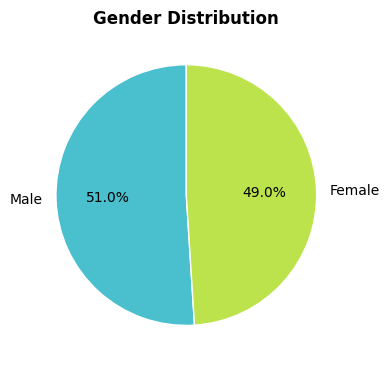

In [263]:
gender_count = df['gender'].value_counts()
plt.figure(figsize=(4, 4))

gender_count.plot(kind='pie', colors=["#4ABFCE", "#BDE34C"], autopct='%1.1f%%',
    startangle=90, wedgeprops={'edgecolor': 'white'})
plt.title('Gender Distribution', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Insight: The workforce is distributed across Male and Female employees with a relatively balanced representation.

Q3. How many employees are in each job role?

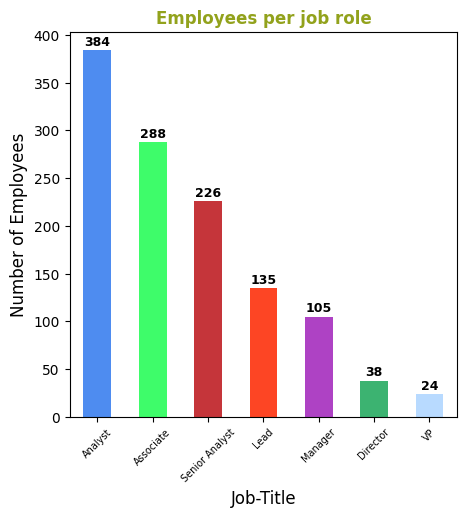

In [264]:
job_role = df['job_role'].value_counts()
plt.figure(figsize=(5, 5))
job_role.plot(kind='bar', color=["#4E8CF0", "#3EFC6A", "#C5353A", "#FD4524", "#AE42C4", '#3CB371', "#B8DAFF"])
plt.title('Employees per job role', fontweight='bold', fontsize=12, color="#92A21C")
plt.xlabel('Job-Title', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.xticks(rotation=45, fontsize=7, fontweight='550')
plt.yticks(fontsize=10, fontweight='550')
for i, v in enumerate(job_role.values):
    plt.text(
        i, v + 5, str(v), ha='center', fontweight='bold', fontsize=9)
plt.show()

 Q4. What is the average salary by job role?

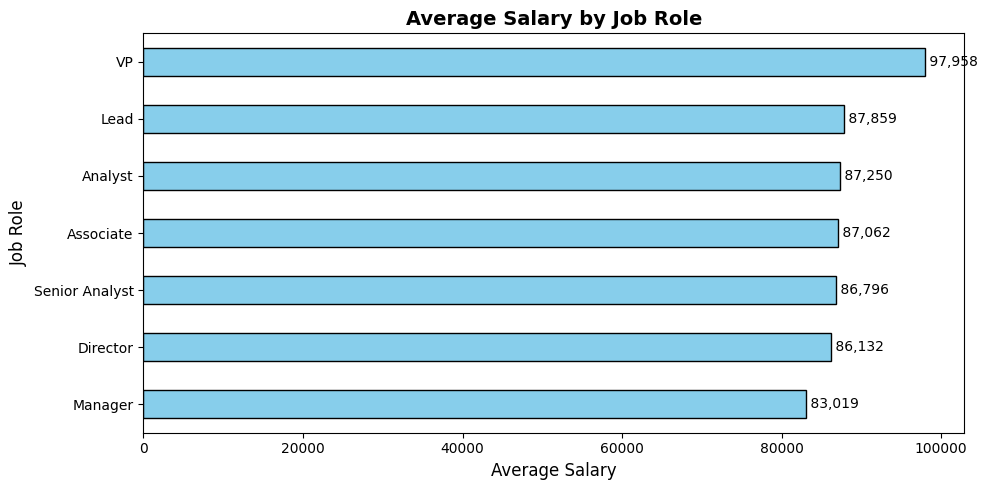

In [265]:
avg_sal = df.groupby('job_role')['salary'].mean().sort_values()
plt.figure(figsize=(10, 5))
avg_sal.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Average Salary by Job Role', fontsize=14, fontweight='bold')
plt.xlabel("Average Salary", fontsize=12)
plt.ylabel('Job Role', fontsize=12)
for i, v in enumerate(avg_sal):
    plt.text(v, i, f' {v:,.0f}', va='center')
plt.tight_layout()
plt.show()

Q5. What is the overall attrition distribution?

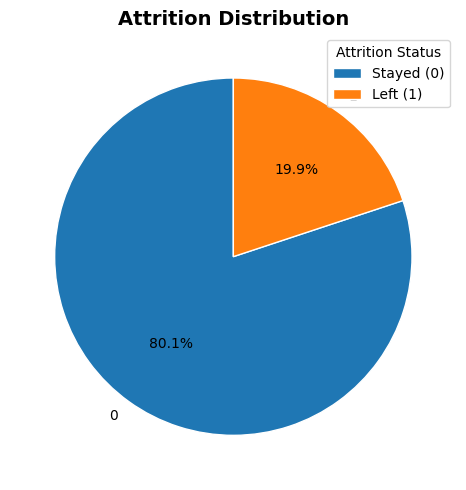

In [266]:
# Pie chart — attrition proportion
att = df['attrition'].value_counts()

plt.figure(figsize=(5, 5))
att.plot(kind='pie', autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white'})
plt.title('Attrition Distribution', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.legend(
    ['Stayed (0)', 'Left (1)'],
    title='Attrition Status',
    loc='upper right'
)
plt.tight_layout()
plt.show()

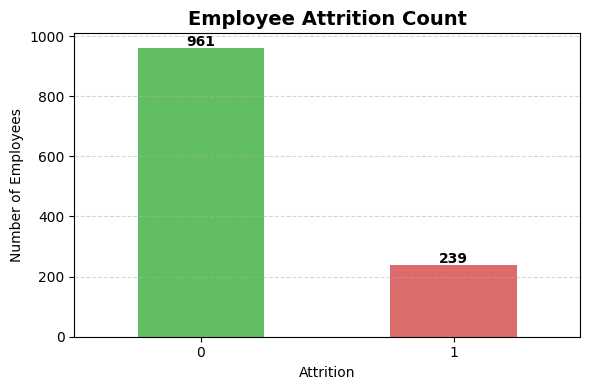

In [267]:
# Bar chart — attrition count
att = df['attrition'].value_counts()

plt.figure(figsize=(6, 4))
att.plot(kind='bar', color=["#61BE62", "#DC6B6B"])
plt.title('Employee Attrition Count', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
for i, v in enumerate(att.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:** Most employees remain with the company while a smaller portion has exited.

 Q6. How does attrition vary by job role?

<Figure size 600x400 with 0 Axes>

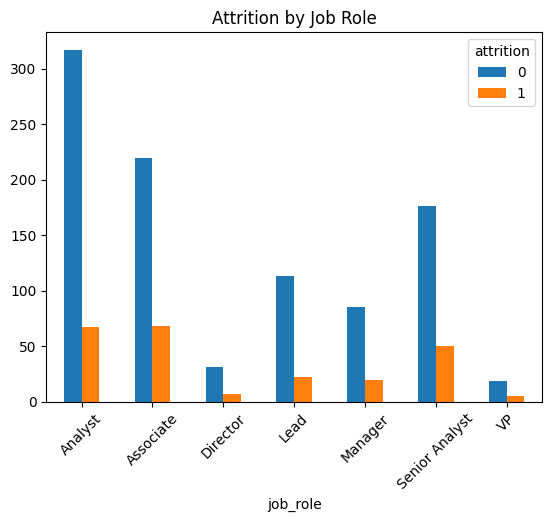

In [268]:
# Cross-tabulate attrition counts by job role
crosstab = pd.crosstab(df['job_role'], df['attrition'])
plt.figure(figsize=(6, 4))
crosstab.plot(kind='bar')
plt.title("Attrition by Job Role")
plt.xticks(rotation=45)
plt.show()

 Q7. What is the attrition trend over time?

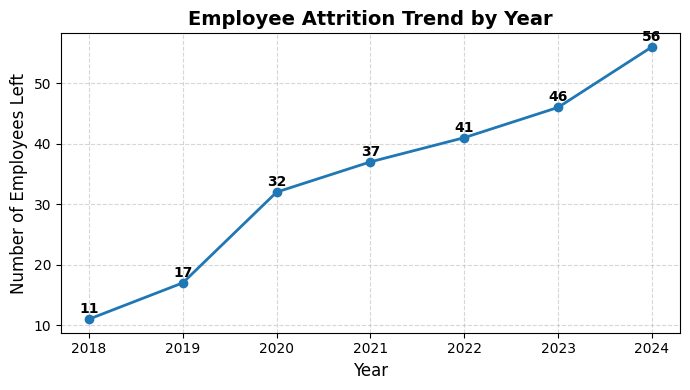

In [269]:
at['attrition_year'] = at['attrition_date'].dt.year
trend = at['attrition_year'].value_counts().sort_index()

plt.figure(figsize=(7, 4))
trend.plot(kind='line', linewidth=2, marker='o')
plt.title('Employee Attrition Trend by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Employees Left', fontsize=12)

for x, y in zip(trend.index, trend.values):
    plt.text(x, y + 1, str(y), ha='center', fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Insight:** Attrition increased over the years and peaked in recent periods.

 Q8. How many employees are in each department?

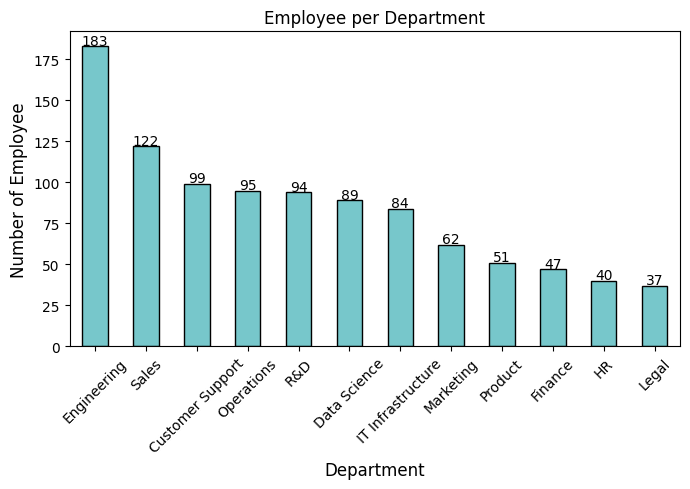

In [270]:
# Merge employee and department tables on dept_id
emp_dpt = df.merge(dt, on='dept_id')
ed = emp_dpt['dept_name'].value_counts()
plt.figure(figsize=(7, 5))
ax = ed.plot(kind='bar', color="#77C7CB", edgecolor='black')
plt.title('Employee per Department')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Number of Employee', fontsize=12)
plt.xticks(rotation=45)

for x, y in enumerate(ed.values):
    plt.text(x, y + 0.9, str(y), ha='center')
plt.tight_layout()
plt.show()

 Q9. Which department has the highest average salary?

In [271]:
# Merge employee and department data, then compute average salary per department
df.merge(dt, on='dept_id')   .groupby('dept_name')['salary']   .mean()   .sort_values(ascending=False)

dept_name
HR                   97725.000000
Marketing            95080.645161
Legal                94864.864865
Finance              91723.404255
R&D                  89393.617021
Engineering          89371.584699
Operations           88842.105263
Customer Support     87080.808081
IT Infrastructure    85273.809524
Data Science         83584.269663
Sales                81860.655738
Product              81705.882353
Name: salary, dtype: float64

Q10. What is the distribution of performance ratings?

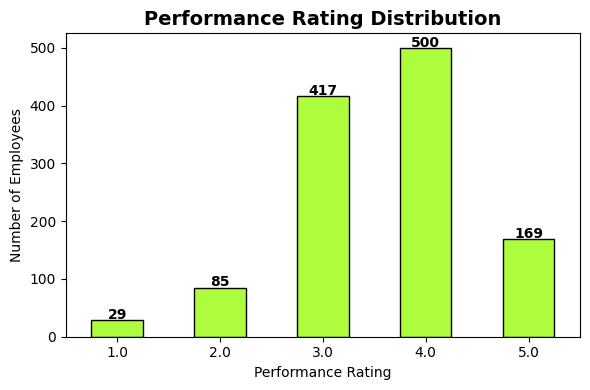

In [272]:
perf = df['performance_rating'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
ax = perf.plot(kind='bar', edgecolor='black', color=["#ADFC3E"])
plt.title('Performance Rating Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Performance Rating')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)

# Add value labels on bars
for i, v in enumerate(perf.values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

 Q11. Which department has the highest attrition?

In [273]:
# Merge employee and department tables, then count attrition by department
df.merge(dt, on='dept_id')   .groupby('dept_name')['attrition']   .value_counts()

dept_name          attrition
Customer Support   0             78
                   1             21
Data Science       0             76
                   1             13
Engineering        0            141
                   1             42
Finance            0             35
                   1             12
HR                 0             33
                   1              7
IT Infrastructure  0             69
                   1             15
Legal              0             30
                   1              7
Marketing          0             51
                   1             11
Operations         0             78
                   1             17
Product            0             46
                   1              5
R&D                0             74
                   1             20
Sales              0             93
                   1             29
Name: count, dtype: int64

Q12. What is the distribution of attrition reasons?

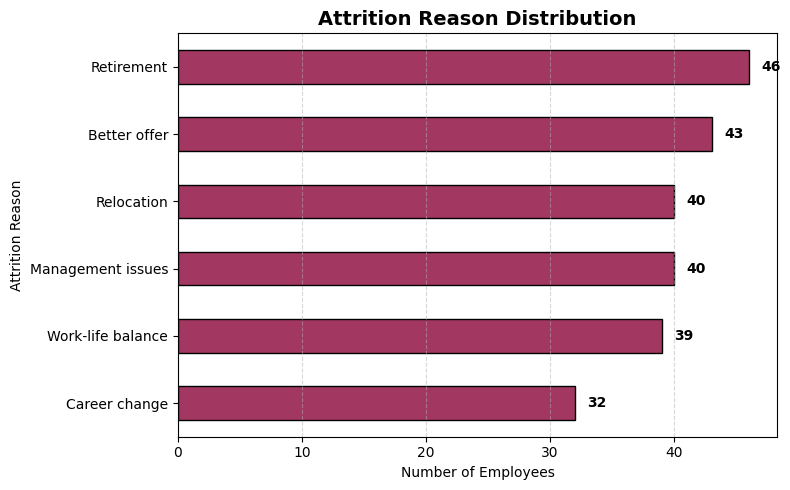

In [274]:
reason_count = at['attrition_reason'].value_counts().sort_values()

plt.figure(figsize=(8, 5))
ax = reason_count.plot(kind='barh', edgecolor='black', color=["#A23762"])
plt.title('Attrition Reason Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of Employees')
plt.ylabel('Attrition Reason')

for i, v in enumerate(reason_count.values):
    plt.text(v + 1, i, str(v), va='center', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()